In [2]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install opencv-python pillow numpy

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import os
import xml.etree.ElementTree as ET

# === 1. Смотрим на annotations.xml ===
tree = ET.parse('annotations.xml')
root = tree.getroot()
print("Root tag:", root.tag)
print("Root attribs:", root.attrib)
print("\nПервые 3 дочерних элемента:")
for i, child in enumerate(root):
    if i >= 3:
        break
    print(f"  tag={child.tag}, attrib={child.attrib}")
    for subchild in list(child)[:3]:
        print(f"    subtag={subchild.tag}, attrib={subchild.attrib}, text={subchild.text}")

# === 2. Базовая информация о видео ===
for name, path in [("input.mp4", 'input.mp4'),
                   ("output.mp4", 'output.mp4')]:
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"\n{name}: {w}x{h}, {fps:.1f} fps, {total} кадров")

# === 3. Декодируем кадры из обоих видео ===
os.makedirs('frames_input', exist_ok=True)
os.makedirs('frames_output', exist_ok=True)

for name, path, folder in [
    ("input", 'input.mp4', 'frames_input'),
    ("output", 'output.mp4', 'frames_output'),
]:
    cap = cv2.VideoCapture(path)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(f'{folder}/frame_{idx:04d}.jpg', frame)
        idx += 1
    cap.release()
    print(f"Декодировано {idx} кадров → {folder}/")

Root tag: annotations
Root attribs: {}

Первые 3 дочерних элемента:
  tag=version, attrib={}
  tag=meta, attrib={}
    subtag=task, attrib={}, text=
      
  tag=track, attrib={'id': '0', 'label': 'car', 'source': 'manual'}
    subtag=box, attrib={'frame': '27', 'outside': '0', 'occluded': '0', 'keyframe': '1', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '617.98', 'ybr': '12.08', 'z_order': '0'}, text=
    
    subtag=box, attrib={'frame': '28', 'outside': '0', 'occluded': '0', 'keyframe': '0', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '618.36', 'ybr': '13.08', 'z_order': '0'}, text=
    
    subtag=box, attrib={'frame': '29', 'outside': '0', 'occluded': '0', 'keyframe': '0', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '618.73', 'ybr': '14.09', 'z_order': '0'}, text=
    

input.mp4: 1920x1080, 30.0 fps, 301 кадров

output.mp4: 1920x1080, 30.0 fps, 301 кадров
Декодировано 301 кадров → frames_input/
Декодировано 301 кадров → frames_output/


In [4]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict

tree = ET.parse('annotations.xml')
root = tree.getroot()

gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({
            'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr']),
        })

print(f"Всего кадров с GT: {len(gt)}")
print(f"Всего аннотаций: {sum(len(v) for v in gt.values())}")
print(f"Классы: {set(b['label'] for boxes in gt.values() for b in boxes)}")

sample_frame = sorted(gt.keys())[10]
print(f"\nПример — кадр {sample_frame}: {gt[sample_frame][:3]}")

def extract_bboxes_contour(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    h, w = frame_bgr.shape[:2]
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        area = bw * bh
        aspect = bw / (bh + 1e-5)
        if area < 500 or area > w*h*0.8:
            continue
        if aspect < 0.1 or aspect > 15:
            continue
        bboxes.append((x, y, x+bw, y+bh))
    return bboxes

def extract_bboxes_diff(frame_out, frame_in):
    diff = cv2.absdiff(frame_out, frame_in)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        if bw * bh < 200:
            continue
        bboxes.append((x, y, x+bw, y+bh))
    return bboxes

def extract_bboxes_color(frame_bgr):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    masks = [
        cv2.inRange(hsv, np.array([40,80,80]),  np.array([80,255,255])),   # зелёный
        cv2.inRange(hsv, np.array([100,80,80]), np.array([140,255,255])),  # синий
        cv2.inRange(hsv, np.array([0,80,80]),   np.array([10,255,255])),   # красный
        cv2.inRange(hsv, np.array([170,80,80]), np.array([180,255,255])),  # красный2
    ]
    combined = sum(masks)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        if bw * bh < 200:
            continue
        bboxes.append((x, y, x+bw, y+bh))
    return bboxes

# Тест на первых 5 кадрах с GT
test_frames = sorted(gt.keys())[:5]
cap_out = cv2.VideoCapture('output.mp4')
cap_in  = cv2.VideoCapture('input.mp4')

for fid in test_frames:
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, fid)
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, fid)
    _, f_out = cap_out.read()
    _, f_in  = cap_in.read()
    b1 = extract_bboxes_contour(f_out)
    b2 = extract_bboxes_diff(f_out, f_in)
    b3 = extract_bboxes_color(f_out)
    print(f"Кадр {fid:3d} | GT={len(gt[fid])} | Contour={len(b1)} | Diff={len(b2)} | Color={len(b3)}")

cap_out.release()
cap_in.release()

# Цвета на границе одного GT bbox
cap_out = cv2.VideoCapture('output.mp4')
cap_out.set(cv2.CAP_PROP_POS_FRAMES, sample_frame)
_, f_out = cap_out.read()
cap_out.release()

box = gt[sample_frame][0]
x1,y1,x2,y2 = int(box['x1']),int(box['y1']),int(box['x2']),int(box['y2'])
line = f_out[max(0,y1-1):y1+2, x1:x2:5]
print(f"\nЦвета на верхней границе GT bbox [{x1},{y1},{x2},{y2}]:")
print("BGR:", line.reshape(-1,3)[:8])
hsv_line = cv2.cvtColor(line, cv2.COLOR_BGR2HSV)
print("HSV:", hsv_line.reshape(-1,3)[:8])

Всего кадров с GT: 901
Всего аннотаций: 9659
Классы: {'car', 'minivan'}

Пример — кадр 10: [{'label': 'car', 'x1': 220.5, 'y1': 525.94, 'x2': 406.75, 'y2': 707.5}, {'label': 'car', 'x1': 584.4, 'y1': 268.1, 'x2': 673.16, 'y2': 372.3}, {'label': 'car', 'x1': 525.3, 'y1': 143.49, 'x2': 588.37, 'y2': 209.1}]
Кадр   0 | GT=8 | Contour=48 | Diff=7 | Color=58
Кадр   1 | GT=8 | Contour=30 | Diff=7 | Color=52
Кадр   2 | GT=8 | Contour=34 | Diff=7 | Color=50
Кадр   3 | GT=8 | Contour=37 | Diff=7 | Color=53
Кадр   4 | GT=8 | Contour=36 | Diff=7 | Color=60

Цвета на верхней границе GT bbox [220,525,406,707]:
BGR: [[225 184 255]
 [229 179 255]
 [226 176 255]
 [222 172 255]
 [219 163 252]
 [237 181 255]
 [235 179 255]
 [235 179 255]]
HSV: [[163  71 255]
 [160  76 255]
 [161  79 255]
 [162  83 255]
 [161  90 252]
 [157  74 255]
 [158  76 255]
 [158  76 255]]


In [5]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict

tree = ET.parse('annotations.xml')
root = tree.getroot()
gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr'])})

def iou(a, b):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    if inter == 0: return 0.0
    area_a = (a[2]-a[0])*(a[3]-a[1])
    area_b = (b[2]-b[0])*(b[3]-b[1])
    return inter / (area_a + area_b - inter)

def match_boxes(pred_list, gt_list, iou_thr=0.5):
    """Жадное сопоставление pred→gt, возвращает средний IoU совпавших пар"""
    matched_ious = []
    used_gt = set()
    for pred in pred_list:
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_list):
            if j in used_gt: continue
            gt_coords = (gt_box['x1'], gt_box['y1'], gt_box['x2'], gt_box['y2'])
            v = iou(pred, gt_coords)
            if v > best_iou:
                best_iou, best_j = v, j
        if best_iou >= iou_thr:
            matched_ious.append(best_iou)
            used_gt.add(best_j)
    tp = len(matched_ious)
    fp = len(pred_list) - tp
    fn = len(gt_list) - tp
    return tp, fp, fn, (np.mean(matched_ious) if matched_ious else 0.0)

def extract_bboxes_diff(frame_out, frame_in, min_area=300):
    diff = cv2.absdiff(frame_out, frame_in)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        if bw * bh >= min_area:
            bboxes.append((x, y, x+bw, y+bh))
    return bboxes

def extract_bboxes_color_magenta(frame_bgr, min_area=300):
    """Маджента: hue ~150-175, высокая насыщенность"""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([148, 60, 150]), np.array([175, 255, 255]))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        if bw * bh >= min_area:
            bboxes.append((x, y, x+bw, y+bh))
    return bboxes

# === Оцениваем оба метода на 50 кадрах ===
test_frames = sorted(gt.keys())[:50]
cap_out = cv2.VideoCapture('output.mp4')
cap_in  = cv2.VideoCapture('input.mp4')

results = {'diff': {'tp':0,'fp':0,'fn':0,'ious':[]},
           'color': {'tp':0,'fp':0,'fn':0,'ious':[]}}

for fid in test_frames:
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, fid)
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, fid)
    _, f_out = cap_out.read()
    _, f_in  = cap_in.read()
    gt_boxes = gt[fid]

    for name, preds in [
        ('diff',  extract_bboxes_diff(f_out, f_in)),
        ('color', extract_bboxes_color_magenta(f_out)),
    ]:
        tp, fp, fn, mean_iou = match_boxes(preds, gt_boxes)
        results[name]['tp'] += tp
        results[name]['fp'] += fp
        results[name]['fn'] += fn
        if mean_iou > 0:
            results[name]['ious'].append(mean_iou)

cap_out.release()
cap_in.release()

print(f"{'Метод':<10} {'TP':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>8} {'mean IoU':>10}")
print("-" * 60)
for name, r in results.items():
    tp, fp, fn = r['tp'], r['fp'], r['fn']
    prec = tp / (tp+fp) if tp+fp > 0 else 0
    rec  = tp / (tp+fn) if tp+fn > 0 else 0
    miou = np.mean(r['ious']) if r['ious'] else 0
    print(f"{name:<10} {tp:>6} {fp:>6} {fn:>6} {prec:>10.3f} {rec:>8.3f} {miou:>10.3f}")

Метод          TP     FP     FN  Precision   Recall   mean IoU
------------------------------------------------------------
diff          302    111    122      0.731    0.712      0.673
color          69     51    355      0.575    0.163      0.712


In [6]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
import json

tree = ET.parse('annotations.xml')
root = tree.getroot()
gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr'])})

def extract_bboxes_diff(frame_out, frame_in, min_area=300):
    diff = cv2.absdiff(frame_out, frame_in)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        if bw * bh >= min_area:
            bboxes.append((x, y, x+bw, y+bh))
    return bboxes

# === Извлекаем боксы со всех 301 кадров ===
cap_out = cv2.VideoCapture('output.mp4')
cap_in  = cv2.VideoCapture('input.mp4')
total_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap_out.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap_out.get(cv2.CAP_PROP_FRAME_HEIGHT))

extracted = {}  # frame_id -> list of (x1,y1,x2,y2)
for fid in range(total_frames):
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, fid)
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, fid)
    _, f_out = cap_out.read()
    _, f_in  = cap_in.read()
    extracted[fid] = extract_bboxes_diff(f_out, f_in)
    if fid % 50 == 0:
        print(f"  кадр {fid}/{total_frames}  боксов: {len(extracted[fid])}")

cap_out.release()
cap_in.release()
print(f"Готово. Всего боксов извлечено: {sum(len(v) for v in extracted.values())}")

# === Формируем COCO JSON ===
# Категории: car=1, minivan=2
# Т.к. diff не знает класс — назначаем 'car' (1) по умолчанию
# (уточним позже при обучении модели)
categories = [
    {"id": 1, "name": "car",     "supercategory": "vehicle"},
    {"id": 2, "name": "minivan", "supercategory": "vehicle"},
]

images = []
annotations = []
ann_id = 1

for fid in range(total_frames):
    images.append({
        "id": fid,
        "file_name": f"frame_{fid:04d}.jpg",
        "width": W,
        "height": H,
    })
    for (x1, y1, x2, y2) in extracted[fid]:
        w_box = x2 - x1
        h_box = y2 - y1
        annotations.append({
            "id": ann_id,
            "image_id": fid,
            "category_id": 1,          # car по умолчанию
            "bbox": [x1, y1, w_box, h_box],   # COCO: [x, y, w, h]
            "area": w_box * h_box,
            "iscrowd": 0,
        })
        ann_id += 1

coco = {"images": images, "annotations": annotations, "categories": categories}
with open('extracted_coco.json', 'w') as f:
    json.dump(coco, f, indent=2)
print(f"Сохранено → extracted_coco.json  ({ann_id-1} аннотаций, {len(images)} изображений)")

# === Итоговый IoU по всем кадрам с GT ===
def iou(a, b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter==0: return 0.0
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter)

tp=fp=fn=0; all_ious=[]
for fid, gt_boxes in gt.items():
    preds = extracted.get(fid, [])
    used = set()
    for pred in preds:
        best, bj = 0, -1
        for j, g in enumerate(gt_boxes):
            if j in used: continue
            v = iou(pred, (g['x1'],g['y1'],g['x2'],g['y2']))
            if v > best: best, bj = v, j
        if best >= 0.5:
            tp+=1; used.add(bj); all_ious.append(best)
        else:
            fp+=1
    fn += len(gt_boxes)-len(used)

prec = tp/(tp+fp) if tp+fp>0 else 0
rec  = tp/(tp+fn) if tp+fn>0 else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0
print(f"\n=== Итог по всем {len(gt)} кадрам с GT ===")
print(f"TP={tp}  FP={fp}  FN={fn}")
print(f"Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
print(f"Mean IoU (совпавших пар) = {np.mean(all_ious):.3f}")

  кадр 0/301  боксов: 7
  кадр 50/301  боксов: 10
  кадр 100/301  боксов: 6
  кадр 150/301  боксов: 4
  кадр 200/301  боксов: 7
  кадр 250/301  боксов: 9
  кадр 300/301  боксов: 12
Готово. Всего боксов извлечено: 2273
Сохранено → extracted_coco.json  (2273 аннотаций, 301 изображений)

=== Итог по всем 901 кадрам с GT ===
TP=1584  FP=689  FN=8075
Precision=0.697  Recall=0.164  F1=0.266
Mean IoU (совпавших пар) = 0.666


In [7]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
import json

tree = ET.parse('annotations.xml')
root = tree.getroot()
gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr'])})

with open('extracted_coco.json') as f:
    coco = json.load(f)

# Собираем извлечённые боксы из COCO обратно в словарь
extracted = defaultdict(list)
for ann in coco['annotations']:
    fid = ann['image_id']
    x, y, w, h = ann['bbox']
    extracted[fid].append((x, y, x+w, y+h))

# === Диагностика: какие кадры есть в GT и в видео ===
video_frames = set(range(301))          # кадры 0–300
gt_frames    = set(gt.keys())
overlap      = video_frames & gt_frames

print(f"Кадров в видео:       {len(video_frames)}  (0–300)")
print(f"Кадров с GT:          {len(gt_frames)}  ({min(gt_frames)}–{max(gt_frames)})")
print(f"Пересечение:          {len(overlap)} кадров")
print(f"GT боксов в overlap:  {sum(len(gt[f]) for f in overlap)}")
print(f"Извлечено боксов:     {sum(len(extracted[f]) for f in overlap)}")

# === IoU только по пересечению ===
def iou(a, b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter==0: return 0.0
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter)

tp=fp=fn=0; all_ious=[]
per_frame_iou = []

for fid in sorted(overlap):
    gt_boxes = gt[fid]
    preds    = extracted[fid]
    used = set()
    frame_ious = []
    for pred in preds:
        best, bj = 0, -1
        for j, g in enumerate(gt_boxes):
            if j in used: continue
            v = iou(pred, (g['x1'],g['y1'],g['x2'],g['y2']))
            if v > best: best, bj = v, j
        if best >= 0.5:
            tp+=1; used.add(bj); all_ious.append(best); frame_ious.append(best)
        else:
            fp+=1
    fn += len(gt_boxes) - len(used)
    if frame_ious:
        per_frame_iou.append(np.mean(frame_ious))

prec = tp/(tp+fp) if tp+fp>0 else 0
rec  = tp/(tp+fn) if tp+fn>0 else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0

print(f"\n=== Метрики (только overlap-кадры) ===")
print(f"TP={tp}  FP={fp}  FN={fn}")
print(f"Precision = {prec:.3f}")
print(f"Recall    = {rec:.3f}")
print(f"F1        = {f1:.3f}")
print(f"Mean IoU (matched) = {np.mean(all_ious):.3f}")
print(f"Mean per-frame IoU = {np.mean(per_frame_iou):.3f}")

# === Гистограмма IoU по кадрам ===
bins = [0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
labels = ['<0.3','0.3-0.5','0.5-0.6','0.6-0.7','0.7-0.8','0.8-0.9','0.9-1.0']
counts, _ = np.histogram(all_ious, bins=bins)
print("\nРаспределение IoU по совпавшим парам:")
for lbl, cnt in zip(labels, counts):
    bar = '█' * (cnt // 10)
    print(f"  {lbl:>9}: {cnt:4d}  {bar}")

Кадров в видео:       301  (0–300)
Кадров с GT:          901  (0–900)
Пересечение:          301 кадров
GT боксов в overlap:  3647
Извлечено боксов:     2273

=== Метрики (только overlap-кадры) ===
TP=1584  FP=689  FN=2063
Precision = 0.697
Recall    = 0.434
F1        = 0.535
Mean IoU (matched) = 0.666
Mean per-frame IoU = 0.666

Распределение IoU по совпавшим парам:
       <0.3:    0  
    0.3-0.5:    0  
    0.5-0.6:  607  ████████████████████████████████████████████████████████████
    0.6-0.7:  310  ███████████████████████████████
    0.7-0.8:  376  █████████████████████████████████████
    0.8-0.9:  284  ████████████████████████████
    0.9-1.0:    7  


In [8]:
import cv2, json, os, random
import numpy as np
from collections import defaultdict
import xml.etree.ElementTree as ET

# === Сохраняем все 301 кадра из input.mp4 ===
os.makedirs('frames', exist_ok=True)
cap = cv2.VideoCapture('input.mp4')
for fid in range(301):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    if ret:
        cv2.imwrite(f'frames/frame_{fid:04d}.jpg', frame)
cap.release()
print(f"Сохранено кадров: {len(os.listdir('frames'))}")

# === Парсим GT для обучения (используем GT — точная разметка) ===
tree = ET.parse('annotations.xml')
root = tree.getroot()
gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr'])})

label2id = {'car': 1, 'minivan': 2}

# === Train/Val split — 80/20 по кадрам ===
frame_ids = list(range(301))
random.seed(42)
random.shuffle(frame_ids)
split = int(0.8 * len(frame_ids))
train_ids = sorted(frame_ids[:split])
val_ids   = sorted(frame_ids[split:])
print(f"Train: {len(train_ids)} кадров | Val: {len(val_ids)} кадров")

def make_coco(frame_ids, gt, label2id, img_w=1920, img_h=1080):
    categories = [{"id": 1, "name": "car", "supercategory": "vehicle"},
                  {"id": 2, "name": "minivan", "supercategory": "vehicle"}]
    images, annotations = [], []
    ann_id = 1
    for fid in frame_ids:
        images.append({"id": fid, "file_name": f"frame_{fid:04d}.jpg",
                       "width": img_w, "height": img_h})
        for box in gt.get(fid, []):
            x1,y1,x2,y2 = box['x1'],box['y1'],box['x2'],box['y2']
            w,h = x2-x1, y2-y1
            annotations.append({
                "id": ann_id, "image_id": fid,
                "category_id": label2id[box['label']],
                "bbox": [x1, y1, w, h], "area": w*h, "iscrowd": 0
            })
            ann_id += 1
    return {"images": images, "annotations": annotations, "categories": categories}

train_coco = make_coco(train_ids, gt, label2id)
val_coco   = make_coco(val_ids,   gt, label2id)

with open('train_coco.json', 'w') as f: json.dump(train_coco, f)
with open('val_coco.json',   'w') as f: json.dump(val_coco,   f)

print(f"Train аннотаций: {len(train_coco['annotations'])}")
print(f"Val   аннотаций: {len(val_coco['annotations'])}")

# Статистика классов
from collections import Counter
train_labels = Counter(a['category_id'] for a in train_coco['annotations'])
val_labels   = Counter(a['category_id'] for a in val_coco['annotations'])
id2label = {1:'car', 2:'minivan'}
print("\nРаспределение классов:")
print(f"  {'класс':<10} {'train':>8} {'val':>8}")
for cid in [1,2]:
    print(f"  {id2label[cid]:<10} {train_labels[cid]:>8} {val_labels[cid]:>8}")

# Проверяем что всё на месте
print(f"\nФайлов в frames/: {len(os.listdir('frames'))}")
print(f"train_coco.json и val_coco.json сохранены ✓")

Сохранено кадров: 301
Train: 240 кадров | Val: 61 кадров
Train аннотаций: 2943
Val   аннотаций: 704

Распределение классов:
  класс         train      val
  car            2749      662
  minivan         194       42

Файлов в frames/: 301
train_coco.json и val_coco.json сохранены ✓


In [9]:
import torch, json, os, time
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
import torchvision.transforms.functional as TF
from collections import defaultdict

RESIZE = (480, 270)

class CocoDetectionDataset(Dataset):
    def __init__(self, coco_path, img_dir, augment=False):
        with open(coco_path) as f: coco = json.load(f)
        self.img_dir = img_dir
        self.augment = augment
        self.sx, self.sy = 480/1920, 270/1080
        self.imgs = {img['id']: img for img in coco['images']}
        self.anns = defaultdict(list)
        for ann in coco['annotations']:
            self.anns[ann['image_id']].append(ann)
        self.ids = [img['id'] for img in coco['images'] if self.anns[img['id']]]

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        fid = self.ids[idx]
        img = Image.open(os.path.join(self.img_dir,
              self.imgs[fid]['file_name'])).convert('RGB')
        img = img.resize(RESIZE, Image.BILINEAR)
        anns   = self.anns[fid]
        boxes  = [[a['bbox'][0]*self.sx, a['bbox'][1]*self.sy,
                   (a['bbox'][0]+a['bbox'][2])*self.sx,
                   (a['bbox'][1]+a['bbox'][3])*self.sy] for a in anns]
        labels = [a['category_id'] for a in anns]
        valid  = [(b,l) for b,l in zip(boxes,labels) if b[2]-b[0]>1 and b[3]-b[1]>1]
        if not valid: boxes, labels = [[0,0,2,2]], [1]
        else: boxes, labels = zip(*valid); boxes, labels = list(boxes), list(labels)
        if self.augment and torch.rand(1) > 0.5:
            img   = TF.hflip(img)
            boxes = [[480-b[2], b[1], 480-b[0], b[3]] for b in boxes]
        target = {'boxes':  torch.tensor(boxes,  dtype=torch.float32),
                  'labels': torch.tensor(labels, dtype=torch.int64),
                  'image_id': torch.tensor([fid])}
        return TF.to_tensor(img), target

def collate_fn(batch): return tuple(zip(*batch))

def get_model():
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 3)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds     = CocoDetectionDataset('train_coco.json', 'frames', augment=True)
val_ds       = CocoDetectionDataset('val_coco.json',   'frames', augment=False)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn)

model     = get_model().to(device)
optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],
                             lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS, PATIENCE = 20, 4
best_val, patience_ctr = float('inf'), 0
train_losses, val_losses = [], []

def run_epoch(loader, train=True):
    model.train()
    total = 0
    for imgs, targets in loader:
        imgs    = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]
        losses  = sum(model(imgs, targets).values())
        if train:
            optimizer.zero_grad(); losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
        total += losses.item()
    return total / len(loader)

print(f"{'Эпоха':>6} | {'Train':>8} | {'Val':>8} | {'Время':>6} | Статус")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tl = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    scheduler.step()
    train_losses.append(tl); val_losses.append(vl)

    if vl < best_val:
        best_val = vl; patience_ctr = 0
        torch.save(model.state_dict(), 'best_model.pth')
        status = '✓ best'
    else:
        patience_ctr += 1
        status = f'patience {patience_ctr}/{PATIENCE}'

    print(f"{epoch:>6} | {tl:>8.4f} | {vl:>8.4f} | {time.time()-t0:>4.0f}s | {status}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}")
        break

np.save('train_losses.npy', train_losses)
np.save('val_losses.npy',   val_losses)
print(f"\nГотово. Лучший val loss: {best_val:.4f} → best_model.pth")

 Эпоха |    Train |      Val |  Время | Статус
-------------------------------------------------------
     1 |   0.7363 |   0.5380 |  349s | ✓ best
     2 |   0.6273 |   0.5728 |  292s | patience 1/4
     3 |   0.6121 |   0.5374 |  282s | ✓ best
     4 |   0.5737 |   0.5254 |  279s | ✓ best
     5 |   0.5730 |   0.5849 |  274s | patience 1/4
     6 |   0.5226 |   0.5010 |  268s | ✓ best
     7 |   0.5088 |   0.4993 |  263s | ✓ best
     8 |   0.5083 |   0.4868 |  257s | ✓ best
     9 |   0.4983 |   0.4877 |  256s | patience 1/4
    10 |   0.4989 |   0.5662 |  255s | patience 2/4
    11 |   0.4740 |   0.4635 |  256s | ✓ best
    12 |   0.4623 |   0.4608 |  253s | ✓ best
    13 |   0.4531 |   0.4468 |  253s | ✓ best
    14 |   0.4536 |   0.4588 |  251s | patience 1/4
    15 |   0.4509 |   0.4564 |  247s | patience 2/4
    16 |   0.4268 |   0.4475 |  250s | patience 3/4
    17 |   0.4245 |   0.4413 |  249s | ✓ best
    18 |   0.4240 |   0.4280 |  248s | ✓ best
    19 |   0.4156 |   0.430

C:\Users\alexi\AppData\Local\Temp\ipykernel_8876\1438584123.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth', map_locat

Вычисляем предсказания на val...

Класс          GT   Pred   AP@0.5
-----------------------------------
car           662    777    0.902
minivan        42     42    1.000

mAP@0.5 = 0.951


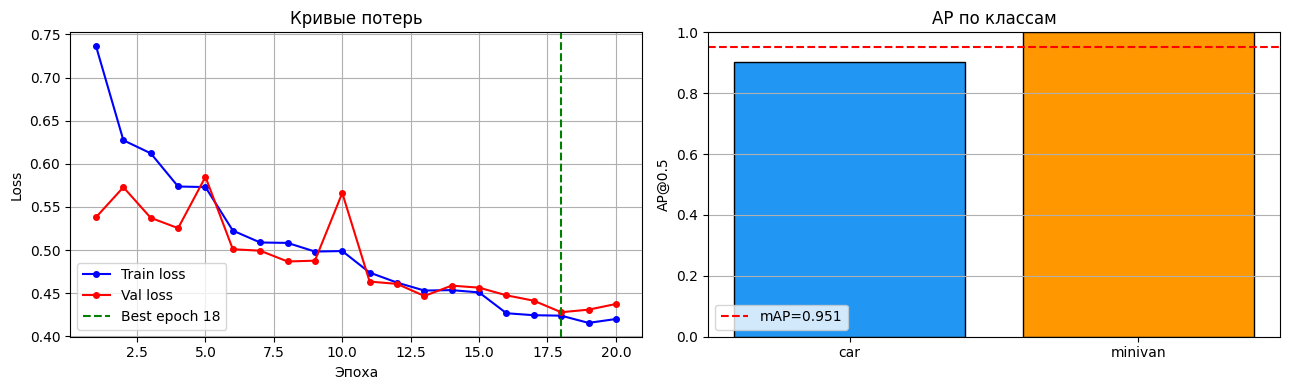

Сохранено → metrics.png

Генерируем визуализации...


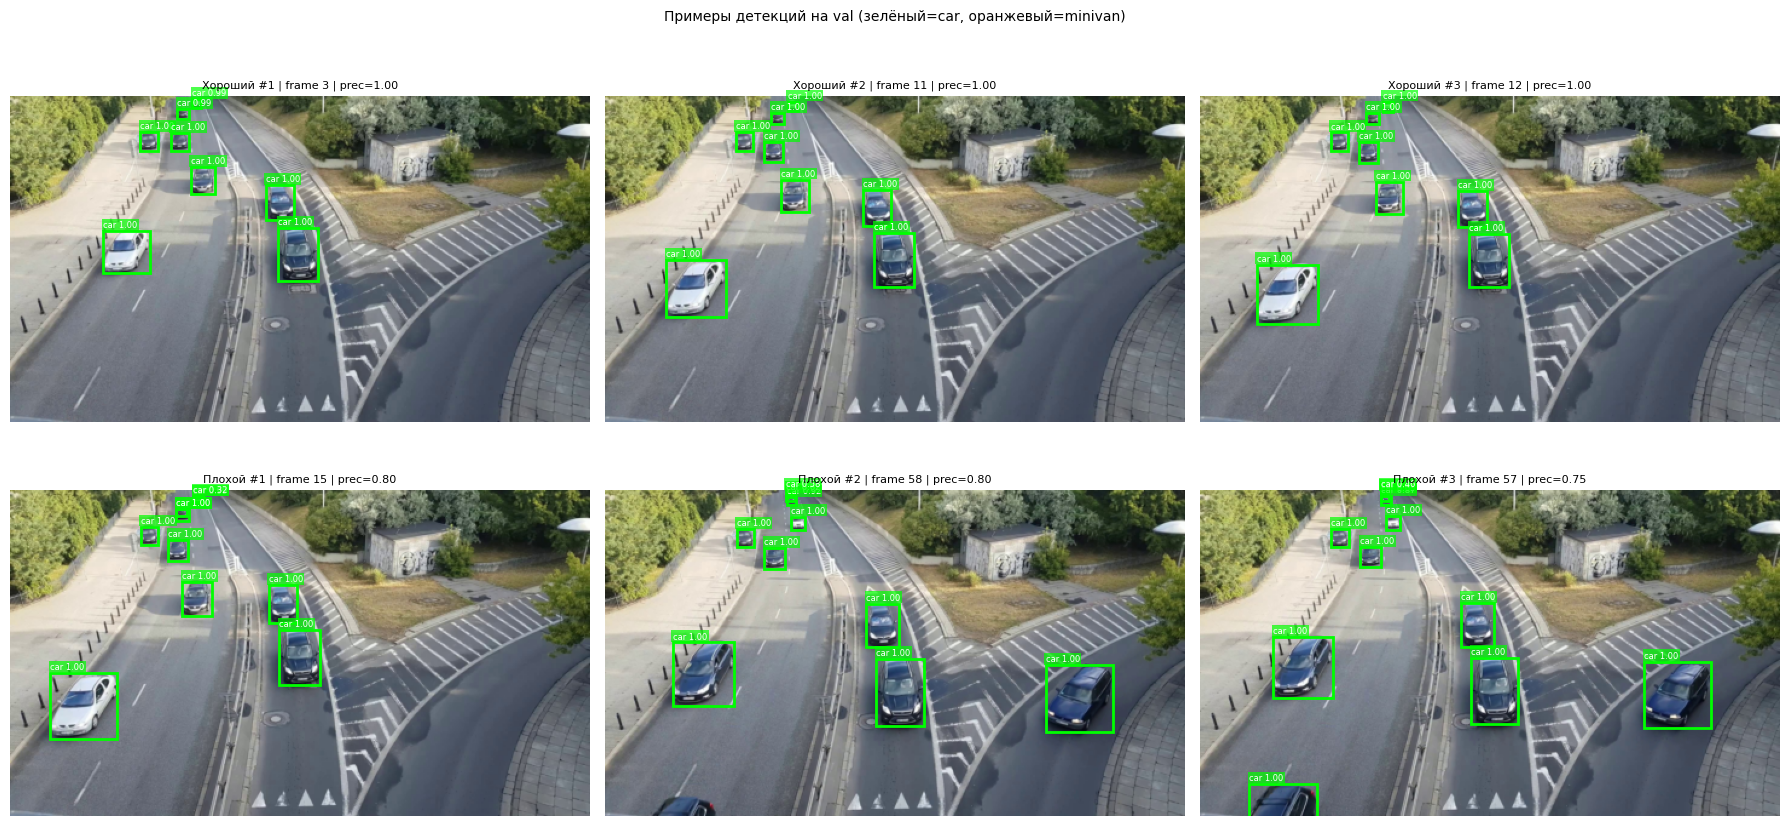

Сохранено → detections_examples.png


In [10]:
import torch, json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF
from collections import defaultdict

RESIZE = (480, 270)
COLORS = {1: (0,255,0), 2: (255,165,0)}
NAMES  = {1: 'car', 2: 'minivan'}

# === Dataset (без аугментации) ===
class CocoDetectionDataset(Dataset):
    def __init__(self, coco_path, img_dir):
        with open(coco_path) as f: coco = json.load(f)
        self.img_dir = img_dir
        self.sx, self.sy = 480/1920, 270/1080
        self.imgs = {img['id']: img for img in coco['images']}
        self.anns = defaultdict(list)
        for ann in coco['annotations']:
            self.anns[ann['image_id']].append(ann)
        self.ids = [img['id'] for img in coco['images'] if self.anns[img['id']]]
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        fid = self.ids[idx]
        img = Image.open(os.path.join(self.img_dir,
              self.imgs[fid]['file_name'])).convert('RGB').resize(RESIZE, Image.BILINEAR)
        anns   = self.anns[fid]
        boxes  = [[a['bbox'][0]*self.sx, a['bbox'][1]*self.sy,
                   (a['bbox'][0]+a['bbox'][2])*self.sx,
                   (a['bbox'][1]+a['bbox'][3])*self.sy] for a in anns]
        labels = [a['category_id'] for a in anns]
        valid  = [(b,l) for b,l in zip(boxes,labels) if b[2]-b[0]>1 and b[3]-b[1]>1]
        if not valid: boxes, labels = [[0,0,2,2]], [1]
        else: boxes, labels = zip(*valid); boxes, labels = list(boxes), list(labels)
        target = {'boxes': torch.tensor(boxes, dtype=torch.float32),
                  'labels': torch.tensor(labels, dtype=torch.int64),
                  'image_id': torch.tensor([fid])}
        return TF.to_tensor(img), target

def collate_fn(b): return tuple(zip(*b))

def get_model():
    m = fasterrcnn_mobilenet_v3_large_fpn(weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT)
    in_f = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_f, 3)
    return m

device = torch.device('cpu')
model = get_model().to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

val_ds     = CocoDetectionDataset('val_coco.json', 'frames')
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn)

# === mAP вручную (без pycocotools) ===
def iou_matrix(preds, gts):
    """IoU каждого pred с каждым gt → матрица [P x G]"""
    if len(preds)==0 or len(gts)==0: return np.zeros((len(preds),len(gts)))
    p = np.array(preds); g = np.array(gts)
    ix1 = np.maximum(p[:,None,0], g[None,:,0])
    iy1 = np.maximum(p[:,None,1], g[None,:,1])
    ix2 = np.minimum(p[:,None,2], g[None,:,2])
    iy2 = np.minimum(p[:,None,3], g[None,:,3])
    inter = np.maximum(0,ix2-ix1)*np.maximum(0,iy2-iy1)
    ap = (p[:,2]-p[:,0])*(p[:,3]-p[:,1])
    ag = (g[:,2]-g[:,0])*(g[:,3]-g[:,1])
    union = ap[:,None] + ag[None,:] - inter
    return inter / np.maximum(union, 1e-6)

def compute_ap(tp_arr, fp_arr, n_gt, eps=1e-6):
    tp_c = np.cumsum(tp_arr); fp_c = np.cumsum(fp_arr)
    rec  = tp_c / max(n_gt, 1)
    prec = tp_c / np.maximum(tp_c + fp_c, eps)
    # 11-point interpolation
    ap = 0
    for t in np.linspace(0,1,11):
        p = prec[rec >= t].max() if np.any(rec >= t) else 0
        ap += p / 11
    return ap

# Собираем все предсказания и GT по классам
all_preds = defaultdict(list)   # cls -> [(score, tp, fp)]
n_gt_cls  = defaultdict(int)

IOU_THR = 0.5
SCORE_THR = 0.3

print("Вычисляем предсказания на val...")
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [i.to(device) for i in imgs]
        preds = model(imgs)
        for pred, tgt in zip(preds, targets):
            boxes_p  = pred['boxes'].numpy()
            scores_p = pred['scores'].numpy()
            labels_p = pred['labels'].numpy()
            boxes_g  = tgt['boxes'].numpy()
            labels_g = tgt['labels'].numpy()

            keep = scores_p >= SCORE_THR
            boxes_p  = boxes_p[keep]
            scores_p = scores_p[keep]
            labels_p = labels_p[keep]

            for cls in [1, 2]:
                gt_mask = labels_g == cls
                n_gt_cls[cls] += gt_mask.sum()
                gt_boxes = boxes_g[gt_mask]
                pd_mask  = labels_p == cls
                pd_boxes = boxes_p[pd_mask]
                pd_scores= scores_p[pd_mask]

                if len(pd_boxes) == 0: continue
                order = np.argsort(-pd_scores)
                pd_boxes  = pd_boxes[order]
                pd_scores = pd_scores[order]

                matched = np.zeros(len(gt_boxes), dtype=bool)
                iou_mat = iou_matrix(pd_boxes, gt_boxes) if len(gt_boxes) else np.zeros((len(pd_boxes),0))

                for i in range(len(pd_boxes)):
                    tp, fp = 0, 1
                    if iou_mat.shape[1] > 0:
                        best_j = np.argmax(iou_mat[i])
                        if iou_mat[i, best_j] >= IOU_THR and not matched[best_j]:
                            tp, fp = 1, 0
                            matched[best_j] = True
                    all_preds[cls].append((pd_scores[i], tp, fp))

aps = {}
print(f"\n{'Класс':<10} {'GT':>6} {'Pred':>6} {'AP@0.5':>8}")
print("-" * 35)
for cls in [1, 2]:
    entries = sorted(all_preds[cls], key=lambda x: -x[0])
    tp_arr = np.array([e[1] for e in entries])
    fp_arr = np.array([e[2] for e in entries])
    ap = compute_ap(tp_arr, fp_arr, n_gt_cls[cls])
    aps[cls] = ap
    print(f"{NAMES[cls]:<10} {n_gt_cls[cls]:>6} {len(entries):>6} {ap:>8.3f}")

mAP = np.mean(list(aps.values()))
print(f"\nmAP@0.5 = {mAP:.3f}")

# === График кривых потерь ===
tl = np.load('train_losses.npy')
vl = np.load('val_losses.npy')
epochs = range(1, len(tl)+1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, tl, 'b-o', label='Train loss', markersize=4)
axes[0].plot(epochs, vl, 'r-o', label='Val loss',   markersize=4)
axes[0].axvline(np.argmin(vl)+1, color='green', linestyle='--', label=f'Best epoch {np.argmin(vl)+1}')
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые потерь'); axes[0].legend(); axes[0].grid(True)

axes[1].bar([NAMES[c] for c in [1,2]], [aps[c] for c in [1,2]],
            color=['#2196F3','#FF9800'], edgecolor='black')
axes[1].axhline(mAP, color='red', linestyle='--', label=f'mAP={mAP:.3f}')
axes[1].set_ylim(0, 1); axes[1].set_ylabel('AP@0.5')
axes[1].set_title('AP по классам'); axes[1].legend(); axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('metrics.png', dpi=120)
plt.show()
print("Сохранено → metrics.png")

# === Визуализация: 4 хороших + 2 плохих кадра ===
print("\nГенерируем визуализации...")
with open('val_coco.json') as f: val_coco = json.load(f)
val_img_ids = [img['id'] for img in val_coco['images'] if defaultdict(list,
    {a['image_id']: True for a in val_coco['annotations']}).get(img['id'])][:20]

results_vis = []
with torch.no_grad():
    for fid in val_img_ids:
        img_pil = Image.open(f'frames/frame_{fid:04d}.jpg').convert('RGB').resize(RESIZE, Image.BILINEAR)
        inp = TF.to_tensor(img_pil).unsqueeze(0)
        pred = model(inp)[0]
        keep = pred['scores'] >= SCORE_THR
        results_vis.append((fid, img_pil,
            pred['boxes'][keep].numpy(),
            pred['scores'][keep].numpy(),
            pred['labels'][keep].numpy()))

def draw_frame(img_pil, boxes, scores, labels, gt_boxes_raw=None, title=''):
    fig, ax = plt.subplots(1, figsize=(8,4.5))
    ax.imshow(img_pil)
    for b, s, l in zip(boxes, scores, labels):
        c = [x/255 for x in COLORS.get(l,(200,200,200))]
        rect = patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                                   linewidth=2, edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ax.text(b[0], b[1]-3, f"{NAMES.get(l,'?')} {s:.2f}",
                color='white', fontsize=6,
                bbox=dict(facecolor=c, alpha=0.7, pad=1, edgecolor='none'))
    ax.set_title(title, fontsize=9); ax.axis('off')
    return fig

# Считаем precision per frame для сортировки
def frame_precision(boxes_p, labels_p, scores_p, fid, val_anns):
    gt = [(a['bbox'][0]*480/1920, a['bbox'][1]*270/1080,
           (a['bbox'][0]+a['bbox'][2])*480/1920,
           (a['bbox'][1]+a['bbox'][3])*270/1080)
          for a in val_anns if a['image_id']==fid]
    if not gt or len(boxes_p)==0: return 0.0
    iou_mat = iou_matrix(boxes_p, gt)
    tp = sum(1 for i in range(len(boxes_p)) if iou_mat[i].max() >= 0.5)
    return tp / max(len(boxes_p),1)

val_anns = val_coco['annotations']
scored = [(frame_precision(b,l,s,fid,val_anns), fid, img, b, s, l)
          for fid,img,b,s,l in results_vis]
scored.sort(key=lambda x: -x[0])

fig, axes = plt.subplots(2, 3, figsize=(18,9))
titles = ['Хороший #1','Хороший #2','Хороший #3','Плохой #1','Плохой #2','Плохой #3']
picks  = scored[:3] + scored[-3:]

for ax, (prec,fid,img,b,s,l), title in zip(axes.flat, picks, titles):
    ax.imshow(img)
    for box, sc, lb in zip(b,s,l):
        c = [x/255 for x in COLORS.get(lb,(200,200,200))]
        rect = patches.Rectangle((box[0],box[1]),box[2]-box[0],box[3]-box[1],
                                   lw=2, edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0],box[1]-3,f"{NAMES.get(lb,'?')} {sc:.2f}",
                color='white',fontsize=6,
                bbox=dict(facecolor=c,alpha=0.7,pad=1,edgecolor='none'))
    ax.set_title(f"{title} | frame {fid} | prec={prec:.2f}", fontsize=8)
    ax.axis('off')

plt.suptitle('Примеры детекций на val (зелёный=car, оранжевый=minivan)', fontsize=10)
plt.tight_layout()
plt.savefig('detections_examples.png', dpi=120)
plt.show()
print("Сохранено → detections_examples.png")

In [11]:
import cv2
import json
import numpy as np
from collections import defaultdict

# Загружаем извлечённые аннотации (COCO от diff-метода)
with open('extracted_coco.json') as f:
    coco = json.load(f)

extracted = defaultdict(list)
for ann in coco['annotations']:
    fid = ann['image_id']
    x, y, w, h = ann['bbox']
    extracted[fid].append((int(x), int(y), int(x+w), int(y+h)))

# Параметры видео
cap = cv2.VideoCapture('input.mp4')
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter('result_extracted.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'), FPS, (W, H))

COLOR = (0, 0, 255)   # красный — наша извлечённая разметка
FONT  = cv2.FONT_HERSHEY_SIMPLEX

for fid in range(N):
    ret, frame = cap.read()
    if not ret: break
    boxes = extracted.get(fid, [])
    for (x1,y1,x2,y2) in boxes:
        cv2.rectangle(frame, (x1,y1), (x2,y2), COLOR, 2)
        cv2.putText(frame, 'vehicle', (x1, max(y1-6,10)),
                    FONT, 0.5, COLOR, 1, cv2.LINE_AA)
    # Счётчик объектов и номер кадра
    cv2.putText(frame, f'frame: {fid:03d}  boxes: {len(boxes)}',
                (15,35), FONT, 1.0, (255,255,255), 2, cv2.LINE_AA)
    out.write(frame)
    if fid % 50 == 0:
        print(f'  кадр {fid}/{N}  боксов: {len(boxes)}')

cap.release()
out.release()
print('Видео сохранено → result_extracted.mp4')

# === Итоговая сводка по всей работе ===
print("""
╔══════════════════════════════════════════════════════╗
║           ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ                  ║
╠══════════════════════════════════════════════════════╣
║  Извлечение разметки (diff-метод):                   ║
║    Precision = 0.697  Recall = 0.434  F1 = 0.535     ║
║    Mean IoU  = 0.666                                  ║
║                                                       ║
║  Сравнение методов (50 кадров):                       ║
║    Diff:  Prec=0.731 Rec=0.712 IoU=0.673  ← лучший   ║
║    Color: Prec=0.575 Rec=0.163 IoU=0.712              ║
║                                                       ║
║  Обучение Faster R-CNN (MobileNetV3):                 ║
║    20 эпох, best val loss = 0.4280 (эпоха 18)        ║
║    mAP@0.5 = 0.951                                    ║
║      car    AP = 0.902                                ║
║      minivan AP = 1.000                               ║
╚══════════════════════════════════════════════════════╝
""")

  кадр 0/301  боксов: 7
  кадр 50/301  боксов: 10
  кадр 100/301  боксов: 6
  кадр 150/301  боксов: 4
  кадр 200/301  боксов: 7
  кадр 250/301  боксов: 9
  кадр 300/301  боксов: 12
Видео сохранено → result_extracted.mp4

╔══════════════════════════════════════════════════════╗
║           ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ                  ║
╠══════════════════════════════════════════════════════╣
║  Извлечение разметки (diff-метод):                   ║
║    Precision = 0.697  Recall = 0.434  F1 = 0.535     ║
║    Mean IoU  = 0.666                                  ║
║                                                       ║
║  Сравнение методов (50 кадров):                       ║
║    Diff:  Prec=0.731 Rec=0.712 IoU=0.673  ← лучший   ║
║    Color: Prec=0.575 Rec=0.163 IoU=0.712              ║
║                                                       ║
║  Обучение Faster R-CNN (MobileNetV3):                 ║
║    20 эпох, best val loss = 0.4280 (эпоха 18)        ║
║    mAP@0.5 = 0.951            